# Custom Data Preprocessing for JPF-WCA Dataset

This script demonstrates how we perform our own data transformations for our own custom dataset. We implement `make_map_fn` functions to extract answers and format each example according to the required structure. The steps include:

- Loading the dataset that we created manually.
- Processing each example using a custom mapping function:
    - Constructing a data item with the fields: `data_source`, `prompt`, `ability`, `reward_model`, and `extra_info`.
- Saving the processed dataset in parquet format locally.
- Copying the local data to HDFS.

You can modify these functions to suit your own dataset or task requirements.


In [5]:
import pandas as pd

df = pd.read_parquet("eval-instruct-v2.parquet")


In [6]:
df

,problem,example_indices,examples,question,answer_index,answer_constants,answer_solution
0,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,2,(declare-const in0 Int)\n(declare-const in1 Int),(assert ( < in1 in0))
1,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,3,(declare-const in0 Int)\n(declare-const in2 In...,(assert (and ( < in0 in1) ( < in2 in0)))
2,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,4,(declare-const in0 Int)\n(declare-const in2 In...,(assert (and (and ( < in0 in1) ( < in1 in2...
3,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,5,(declare-const in0 Int)\n(declare-const in2 In...,(assert (and (and (and ( < in0 in1) ( < in...
4,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,6,(declare-const in5 Int)\n(declare-const in0 In...,(assert (and (and (and (and ( < in0 in1) ( ...
...,...,...,...,...,...,...,...
24745,ComplexHalfEqual,"[18, 19, 20, 21, 22, 23, 24, 25, 26, 27]","[{'index': 18, 'solution': '(assert (and (and ...",<|im_start|>system\nYou are a helpful assistan...,29,(declare-const in20 Int)\n(declare-const in22 ...,(assert (and (and (and (and (and (and (and (an...
24746,ComplexHalfEqual,"[18, 19, 20, 21, 22, 23, 24, 25, 26, 27]","[{'index': 18, 'solution': '(assert (and (and ...",<|im_start|>system\nYou are a helpful assistan...,30,(declare-const in20 Int)\n(declare-const in22 ...,(assert (and (and (and (and (and (and (and (an...
24747,ComplexHalfEqual,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28]","[{'index': 19, 'solution': '(assert (and (and ...",<|im_start|>system\nYou are a helpful assistan...,29,(declare-const in20 Int)\n(declare-const in22 ...,(assert (and (and (and (and (and (and (and (an...
24748,ComplexHalfEqual,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28]","[{'index': 19, 'solution': '(assert (and (and ...",<|im_start|>system\nYou are a helpful assistan...,30,(declare-const in20 Int)\n(declare-const in22 ...,(assert (and (and (and (and (and (and (and (an...


In [8]:
df.loc[0]

problem                                           SimpleAscendingLast
example_indices                                                   [1]
examples                             [{'index': 1, 'solution': None}]
question            <|im_start|>system\nYou are a helpful assistan...
answer_index                                                        2
answer_constants     (declare-const in0 Int)\n(declare-const in1 Int)
answer_solution                               (assert  ( <  in1 in0))
Name: 0, dtype: object

In [9]:
# Check if any row the examples array's solution is all None
df["examples"].apply(lambda x: all([e["solution"] is None for e in x])).any()

True

In [10]:
# Show all the rows that have examples with all None solutions
df[df["examples"].apply(lambda x: all([e["solution"] is None for e in x]))]

,problem,example_indices,examples,question,answer_index,answer_constants,answer_solution
0,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,2,(declare-const in0 Int)\n(declare-const in1 Int),(assert ( < in1 in0))
1,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,3,(declare-const in0 Int)\n(declare-const in2 In...,(assert (and ( < in0 in1) ( < in2 in0)))
2,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,4,(declare-const in0 Int)\n(declare-const in2 In...,(assert (and (and ( < in0 in1) ( < in1 in2...
3,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,5,(declare-const in0 Int)\n(declare-const in2 In...,(assert (and (and (and ( < in0 in1) ( < in...
4,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,6,(declare-const in5 Int)\n(declare-const in0 In...,(assert (and (and (and (and ( < in0 in1) ( ...
...,...,...,...,...,...,...,...
23625,ComplexHalfEqual,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,2,(declare-const in0 Int)\n(declare-const in1 Int),(assert ( = in0 in1))
23626,ComplexHalfEqual,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,3,(declare-const in0 Int)\n(declare-const in2 In...,(assert (and ( = in0 in1) ( < in1 in2)))
23627,ComplexHalfEqual,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,4,(declare-const in0 Int)\n(declare-const in2 In...,(assert (and (and ( = in0 in1) ( = in1 in2...
23628,ComplexHalfEqual,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\nYou are a helpful assistan...,5,(declare-const in0 Int)\n(declare-const in2 In...,(assert (and (and (and ( = in0 in1) ( = in...


In [11]:
df.drop(df[df["examples"].apply(lambda x: all([e["solution"] is None for e in x]))].index, inplace=True)

In [12]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")

# Remove all the question that are greater than 1.8k tokens
print("Before filtering", len(df))

df.drop(df[df["question"].apply(lambda x: len(tokenizer(x)["input_ids"])) > 1000].index, inplace=True)

print("After filtering", len(df))

/Users/dankoh/ConStruct-veRL/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Before filtering 23595


Token indices sequence length is longer than the specified maximum sequence length for this model (135679 > 131072). Running this sequence through the model will result in indexing errors


After filtering 10438


In [20]:
def make_map_fn(split):
    def process_fn(row):
        data = {
            "data_source": "dannkoh/ConStruct-Base",
            "prompt": [{"role": "user", "content": row["question"]}],
            "ability": "generalisation",
            "reward_model": {"style": "rule", "ground_truth": row["answer_solution"]},
            "extra_info": {
                "answer_constants": row["answer_constants"],
                "answer_index": row["answer_index"],
                "example_indices": row["example_indices"],
            },
        }
        return data

    return process_fn

In [21]:
# Split the data into 2 parts: one for training and one for testing (75% training, 25% testing)
train = df.sample(frac=0.75, random_state=0)
test = df.drop(train.index)

train_dataset = pd.DataFrame(train.apply(make_map_fn("train"), axis=1).tolist())
test_dataset = pd.DataFrame(test.apply(make_map_fn("test"), axis=1).tolist())

In [22]:
train_dataset.to_parquet("train-instruct-v2.parquet")
test_dataset.to_parquet("test-instruct-v2.parquet")

In [23]:
train_dataset

,data_source,prompt,ability,reward_model,extra_info
0,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const in0 Int) ...
1,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const in6 Int) ...
2,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const in6 Int) ...
3,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const in0 Int) ...
4,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const put10_0 I...
...,...,...,...,...,...
7823,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert ( ...",{'answer_constants': '(declare-const in2 Int)'...
7824,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const in6 Int) ...
7825,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const in20 Int)...
7826,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const in0 Int) ...


In [12]:
# max, min, mean prompt token length of qwen tokenizer

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")

print("Max prompt token length:", df["question"].apply(tokenizer.tokenize).apply(len).max())
print("Min prompt token length:", df["question"].apply(tokenizer.tokenize).apply(len).min())
print("Mean prompt token length:", df["question"].apply(tokenizer.tokenize).apply(len).mean())

Max prompt token length: 1800


KeyboardInterrupt: 

count    10438.000000
mean       603.511113
std        198.260755
min        313.000000
25%        427.000000
50%        576.000000
75%        765.000000
max       1000.000000
Name: token_length, dtype: float64

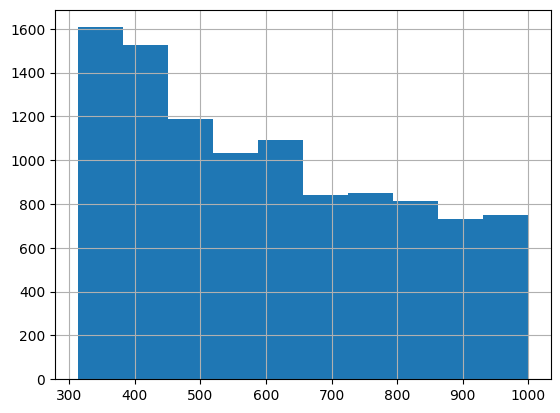

In [24]:
temp = df.copy()
temp["token_length"] = df["question"].apply(tokenizer.tokenize).apply(len)

temp["token_length"].hist()

temp["token_length"].describe()

In [26]:
# get tokenized prompt length distribution

distribution = df["question"].apply(tokenizer.tokenize).apply(len).value_counts().sort_index()

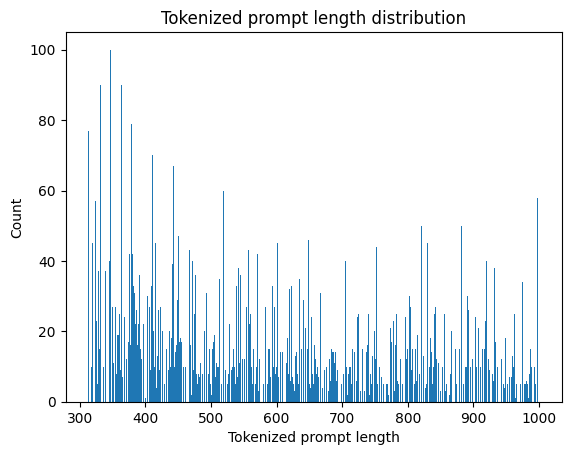

903.0

In [27]:
# Plot distribution and take a subset of the data to use.
import matplotlib.pyplot as plt

plt.bar(distribution.index, distribution.values)
plt.xlabel("Tokenized prompt length")
plt.ylabel("Count")
plt.title("Tokenized prompt length distribution")
plt.show()

# Take the 90th percentile of the data
df["question"].apply(tokenizer.tokenize).apply(len).quantile(0.9)